# Phase segmentation

The goal of this notebook is to divide a standing backflip into distinct phases using biomechanical features extracted from the model. Rather than analyzing the entire movement as single time series, we aim to identify key events and analyze each phase independently. This should allow us to extract more meaningful features and provide phase-specific feedback.
</br>

We defined six phases:
- 1) Set: From the initial position to the maximum knee flexion.
- 2) Takeoff: From maximum knee flexion until the feet leave the ground.
- 3) Tuck: From the takeoff until the athlete starts opening the body.
- 4) Opening: From the begining of body extension until initial ground contact.
- 5) Landing: From initial ground contact until maximum knee flexion during impact absorption.
- 6) Finish: From maximum landing flexion until the athlete completes their final extension.

In [25]:
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import sys

sys.path.insert(0, "../src")
from backflipanalysis.featuresEng import calculate_angle_series, get_video_properties
from backflipanalysis.phases import detect_set

df_mp = pd.read_csv("../data/mediapipe_keypoints.csv")

## Methodology

The initial approach is rule-based. We try to see wether key events can be identified using local minima and maxima of joint angles. Each event will define a boundary between two phases.

You can find the functions I used here in src/featuresEng.py but at this point you have already seen what's under the hood and I just did not want to repeat myself too much.

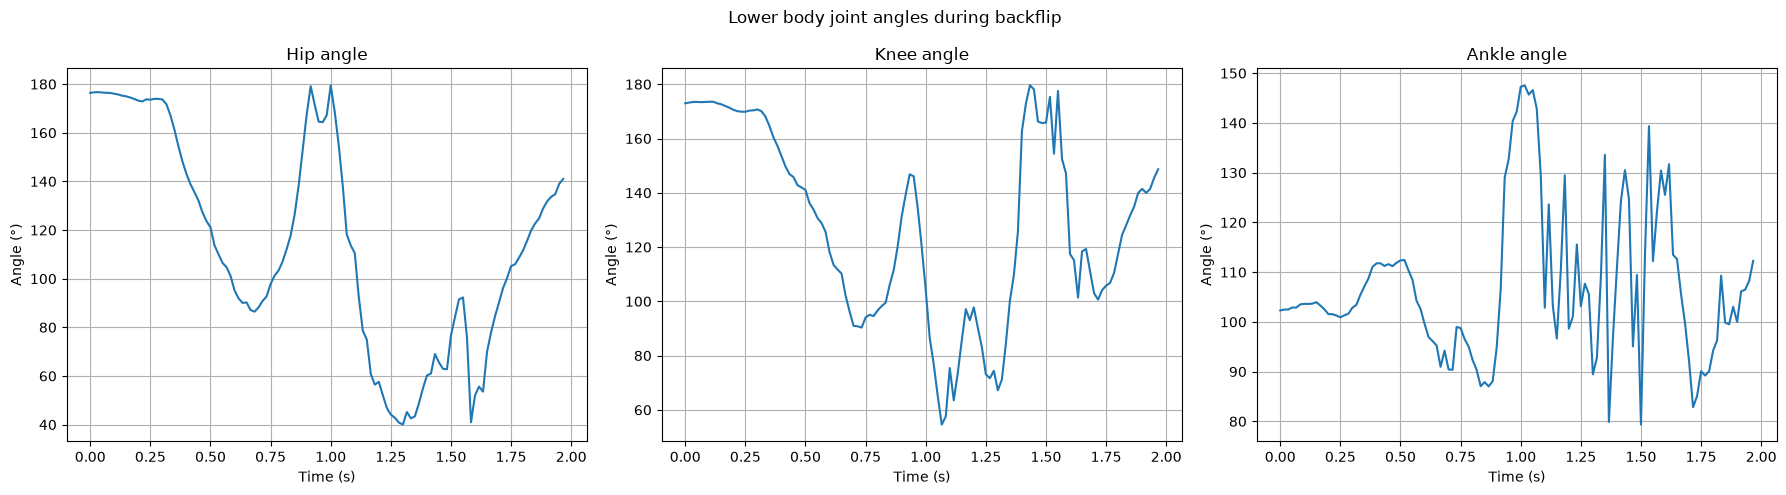

In [26]:
width, height, fps = get_video_properties("../assets/backflip.mov")

df_hip = calculate_angle_series(df=df_mp, a="right_shoulder", b="right_hip", c="right_knee", width=width, height=height, fps=60)
df_knee = calculate_angle_series(df=df_mp, a="right_hip", b="right_knee", c="right_ankle", width=width, height=height, fps=60)
df_ankle = calculate_angle_series(df=df_mp, a="right_knee", b="right_ankle", c="right_foot_index", width=width, height=height, fps=60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

joints = {
    "Hip": df_hip,
    "Knee": df_knee,
    "Ankle": df_ankle
}

for ax, (name, df) in zip(axes, joints.items()):
    ax.plot(df["time"], df["angle"])
    ax.set_title(f"{name} angle")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angle (°)")
    ax.grid()

plt.suptitle("Lower body joint angles during backflip")
plt.tight_layout()
plt.show()

### Set

We define the set as the period between the begining of the movement and the point of maximal knee flexion. As we can see on the graph, its a local minimum though. Therefore, we identify it by looking at the first change in sign of the derivative.

In [27]:
velocity = np.gradient(df_knee['angle'], df_knee['time'])
velocity

array([ 1.58467666e+01,  1.40726175e+01,  7.06309583e+00, -2.08956728e+00,
       -6.70772467e-01,  4.69411420e+00,  2.77578992e+00, -1.73203485e+01,
       -2.83330052e+01, -2.93447192e+01, -3.78037593e+01, -4.21364638e+01,
       -3.82473889e+01, -2.06923320e+01, -6.62926616e+00,  1.17725143e+01,
        1.55619002e+01,  1.29769019e+01, -9.29955908e+00, -7.82397055e+01,
       -1.62936993e+02, -2.30609305e+02, -2.19743877e+02, -2.06438020e+02,
       -2.27429112e+02, -1.99319897e+02, -1.18284814e+02, -1.22989366e+02,
       -1.14476983e+02, -5.34541071e+01, -1.73875852e+02, -2.15268554e+02,
       -1.64392497e+02, -1.49612489e+02, -1.53176665e+02, -3.21172975e+02,
       -3.64407912e+02, -1.92279140e+02, -9.69164381e+01, -2.88282102e+02,
       -4.18426543e+02, -3.34915643e+02, -1.64134912e+02, -1.94264855e+01,
        9.80982713e+01,  1.41967618e+02,  1.51382268e+01,  4.80396959e+01,
        1.10372752e+02,  8.48749421e+01,  2.33494770e+02,  3.57961344e+02,
        4.26650991e+02,  

Basically this array gives us the angular speed of the knee in °/s for every frame.

In [28]:
candidates = np.where((velocity[:-1] < 0) & (velocity[1:] >= 0))[0] + 1

print(candidates)

[  5  15  44  65  68  76  79  90  92  98 103 116]


We can see that the 5th and 15th frames are potential candidates, but I know from watching the video that they correspond to minor local minima caused by oscillations in the knee angle.

It is confirmed here when we take a look at the flexion for every frame, the real flexion is in the 44th.

In [29]:
candidate_df = df_knee.iloc[candidates][["frame", "time", "angle"]]

initial_angle = df_knee["angle"].iloc[0]

candidate_df = candidate_df.copy()

candidate_df["flexion"] = (initial_angle - candidate_df["angle"])

display(candidate_df)

,frame,time,angle,flexion
5,5,0.083333,173.466827,-0.477190
15,15,0.250000,169.858906,3.130731
44,44,0.733333,90.320468,82.669169
65,65,1.083333,57.562767,115.426870
68,68,1.133333,73.649578,99.340059
76,76,1.266667,71.646760,101.342877
79,79,1.316667,71.149046,101.840591
90,90,1.500000,165.873783,7.115854
92,92,1.533333,154.385783,18.603854
98,98,1.633333,101.389517,71.600120


I remade this approach in a function so its more convenient, you can find it in phases.py

In [30]:
set_end_frame = detect_set(df_knee)
print(set_end_frame)

44


### Takeoff

We define the takeoff as the period from maximum knee flexion until the feet leave the ground. We already have the maximum knee flexion frame's index from the set. Unfortunately MediaPipe does not provide a ground landmark, so we will try different approaches to still detect the moment of takeoff.

#### Y coordinates

If we track the y-coordinates of the feet, they should remain relatively stable until takeoff. However, this approach may lack accuracy, and it becomes unreliable if the camera moves vertically.

To make the takeoff detection adaptative, we first estimate the natural varaition of the foot landmarks while the athlete is still on the ground. This variation is kept as a noise baseline.

In [50]:
toe_data = df_mp[df_mp['keypoint']=='right_foot_index']['y']
heel_data = df_mp[df_mp['keypoint']=='right_heel']['y']
display(toe_data.head())

toe = toe_data.median()
heel= heel_data.median()

toe_noise = np.median(np.abs(toe_data - toe))
heel_noise = np.median(np.abs(heel_data - heel))

print("Toe noise: ", toe_noise)
print("Heel noise: ", heel_noise)

32     0.600865
65     0.600139
98     0.600064
131    0.600023
164    0.600057
Name: y, dtype: float64

Toe noise:  0.0037571191787719727
Heel noise:  0.008269011974334717


We can then define a threshold as a multiple of this noise level for example 2 * noise to detect a significant upward movement of the foot.